In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from datetime import datetime

In [2]:
# study area centroid coordinates
centroid_point = (-43.089, -25.456)  # (lon, lat)

In [526]:
# define the relevant date for analysis

relevant_date = datetime(2022,7,17,0,0,0)

# calculate the start and end dates for the analysis period (5-day window around the relevant date)
start_date = relevant_date - pd.Timedelta(days=4)
end_date = relevant_date + pd.Timedelta(days=1)

print(f"Analyzing period from {start_date.date()} to {end_date.date()} around DNS date {relevant_date.date()}")

year = start_date.year
month = end_date.month


Analyzing period from 2022-07-13 to 2022-07-18 around DNS date 2022-07-17


# meteocean data processing

## wave dataset

In [527]:
# load wave dataset
wave_height_ds = xr.open_dataset(f"D:/SARC_LISA_2024/01_dados_brutos/dados_de_reanalise/02_parametros_fisicos/ERA5_2016_2023/wave_parameters_2016_2024/wave_ERA5_{year}.nc")
wave_period_ds = xr. open_dataset("D:/SARC_LISA_2024/01_dados_brutos/dados_de_reanalise/02_parametros_fisicos/ERA5_2016_2023/wave_parameters_2016_2024/wave_period_2016_2024.nc")

wave_ds = wave_height_ds.merge(wave_period_ds, join='inner')

# filter data based on defined period
wave_ds = wave_ds.sel(valid_time=slice(start_date, end_date))

In [528]:
density = 1025  # kg/m³
gravity = 9.81  # m/s²

wave_ds['e_flux'] = (density * (gravity ** 2) * wave_ds['swh'] ** 2 * wave_ds['mwp']) / (64 * np.pi) # W/m
# change for kW/m
wave_ds['e_flux'] = wave_ds['e_flux'] / 1000  # kW/m

In [529]:
# Adjust parameters
dataset = wave_ds # wind_ds # wave_ds # current_ds # msl_ds
variable_name = 'swh'  # 'swh'  # wind_speed  # 'current_speed' # 'e_flux' # 'msl'
variable_label ='Significant Wave Height (m)'  # Significant Wave Height (m)  # Wind Speed (m/s)  # Current Speed (m/s) # 'Wave Energy Flux (kW/m)' # Mean Sea Level Pressure (hPa)
unit = 'm'  # 'm'  # 'm/s'  # 'm/s' # 'kW/m' # 'hPa'

lat = dataset.latitude
lon = dataset.longitude

In [530]:
# separe data per day
day_01 = dataset[variable_name].sel(valid_time=slice(start_date, start_date + pd.Timedelta(days=1)))
day_02 = dataset[variable_name].sel(valid_time=slice(start_date + pd.Timedelta(days=1), start_date + pd.Timedelta(days=2)))
day_03 = dataset[variable_name].sel(valid_time=slice(start_date + pd.Timedelta(days=2), start_date + pd.Timedelta(days=3)))
day_04 = dataset[variable_name].sel(valid_time=slice(start_date + pd.Timedelta(days=3), start_date + pd.Timedelta(days=4)))
day_05 = dataset[variable_name].sel(valid_time=slice(start_date + pd.Timedelta(days=4), start_date + pd.Timedelta(days=5)))
day_06 = dataset[variable_name].sel(valid_time=slice(start_date + pd.Timedelta(days=5), start_date + pd.Timedelta(days=6)))


days = [day_01, day_02, day_03, day_04, day_05,day_06]

day_labels = [
    f"Day 1: {start_date.date()}",
    f"Day 2: {(start_date + pd.Timedelta(days=1)).date()}",
    f"Day 3: {(start_date + pd.Timedelta(days=2)).date()}",
    f"Day 4: {(start_date + pd.Timedelta(days=3)).date()}",
    f"Day 5: {(start_date + pd.Timedelta(days=4)).date()}",
    f"Day 6: {(start_date + pd.Timedelta(days=5)).date()}"
]

# find the overall min and max for consistent color scale
all_days_data = [day.mean(dim = 'valid_time') for day in days]
global_min = np.nanmin([np.nanmin(day_data.values) for day_data in all_days_data])
global_max = np.nanmax([np.nanmax(day_data.values) for day_data in all_days_data])


C:\Users\locfa\AppData\Local\Temp\ipykernel_18580\2657151439.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


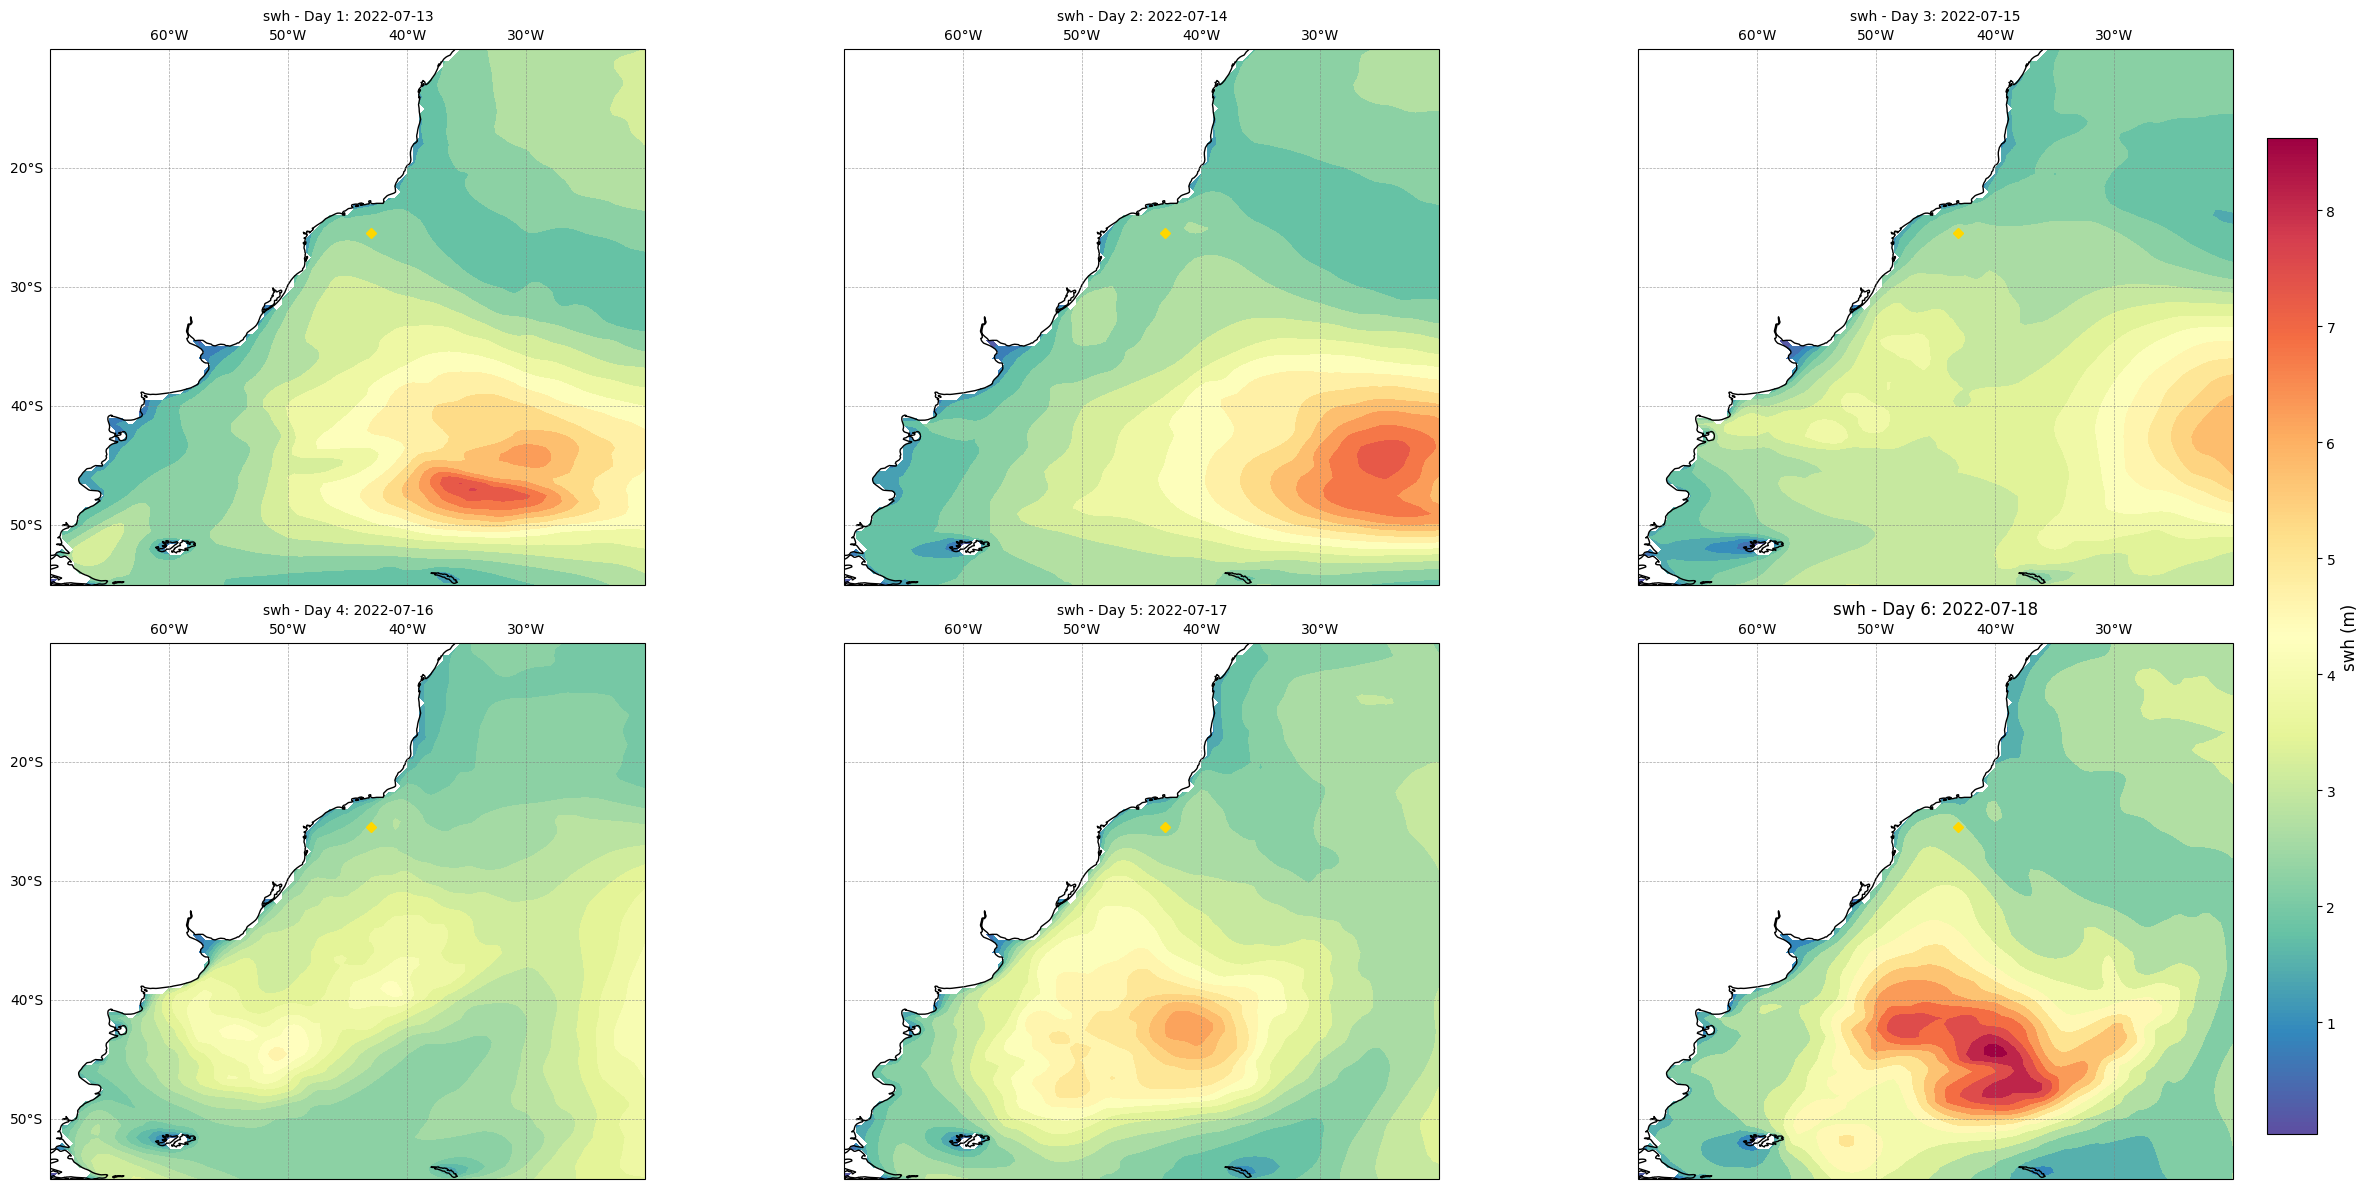

In [531]:

# --- Create figure with consistent color scaling ---
fig = plt.figure(figsize=(25, 12))  # Slightly taller figure to accommodate colorbar
axes = []

# Create a single colorbar for all plots with fixed range
norm = plt.Normalize(vmin=global_min, vmax=global_max)
sm = plt.cm.ScalarMappable(cmap='Spectral_r', norm=norm)
sm.set_array([])  # Empty array, we just need the colormap and normalization

for i in range(len(days)):
    ax = fig.add_subplot(2, 3, i+1, projection=ccrs.PlateCarree())
    axes.append(ax)

for i, (day_data, day_label) in enumerate(zip(days, day_labels)):
    # --- Contour plot with fixed color range ---
    contour = axes[i].contourf(
        lon, lat, day_data.mean(dim='valid_time'), 
        cmap='Spectral_r', 
        transform=ccrs.PlateCarree(),
        norm=norm,  # Use the fixed normalization
        levels=15,
        # alpha = 0.9
    )

    # --- Coastlines and gridlines ---
    axes[i].coastlines()
    gl = axes[i].gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.7, linestyle='--')
    gl.top_labels = True
    gl.left_labels = True
    gl.right_labels = False
    gl.bottom_labels = False
    

    axes[i].plot(
        centroid_point[0], centroid_point[1],
        'D',
        color = 'gold',
        markersize=5,
        transform=ccrs.PlateCarree(),
        label='Centro da área de interesse'  # 'Centro da área de interesse'
    )
    
    # --- Labels and title ---
    axes[i].set_xlabel('Longitude')
    axes[i].set_ylabel('Latitude')
    axes[i].set_title(f'{variable_name} - {day_label}', fontsize=10)

    # Remove latitude labels for subplots 1, 2, 4, 5
    if i in [1,2,4,5]:  # Corresponds to subplots 1, 2, 4, 5 (0-indexed)
        gl.left_labels = False

    # Remove labels from subplots 0, 1, 2 (title, x-axis, y-axis labels)
    if i in [0, 1, 2]:
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_title(f'{day_label}', fontsize=10) # Keep only the date
    else:
        ax.set_title(f'{variable_name} - {day_label}', fontsize=12)


# Add a single vertical colorbar at the bottom center
cbar_ax = fig.add_axes([0.95, 0.05, 0.02, 0.83])  # [deslocamento horizaontal, deslocamento vertical, width, height] 
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='vertical')
cbar.set_label(f'{variable_name} ({unit})', fontsize=12)
cbar.ax.tick_params(labelsize=10)  # Adjust colorbar tick label size

# Adjust layout to make space for the colorbar at the bottom
plt.tight_layout()
# plt.subplots_adjust(bottom=0.05)  # Make extra space at the bottom

plt.savefig(f"D:/SARC_LISA_2024/04_dados_finais/figuras_dns_maps/relevant_dates/{relevant_date.date()}_{variable_name}_maps_dns.png", dpi=300)
# Show the plot
plt.show()

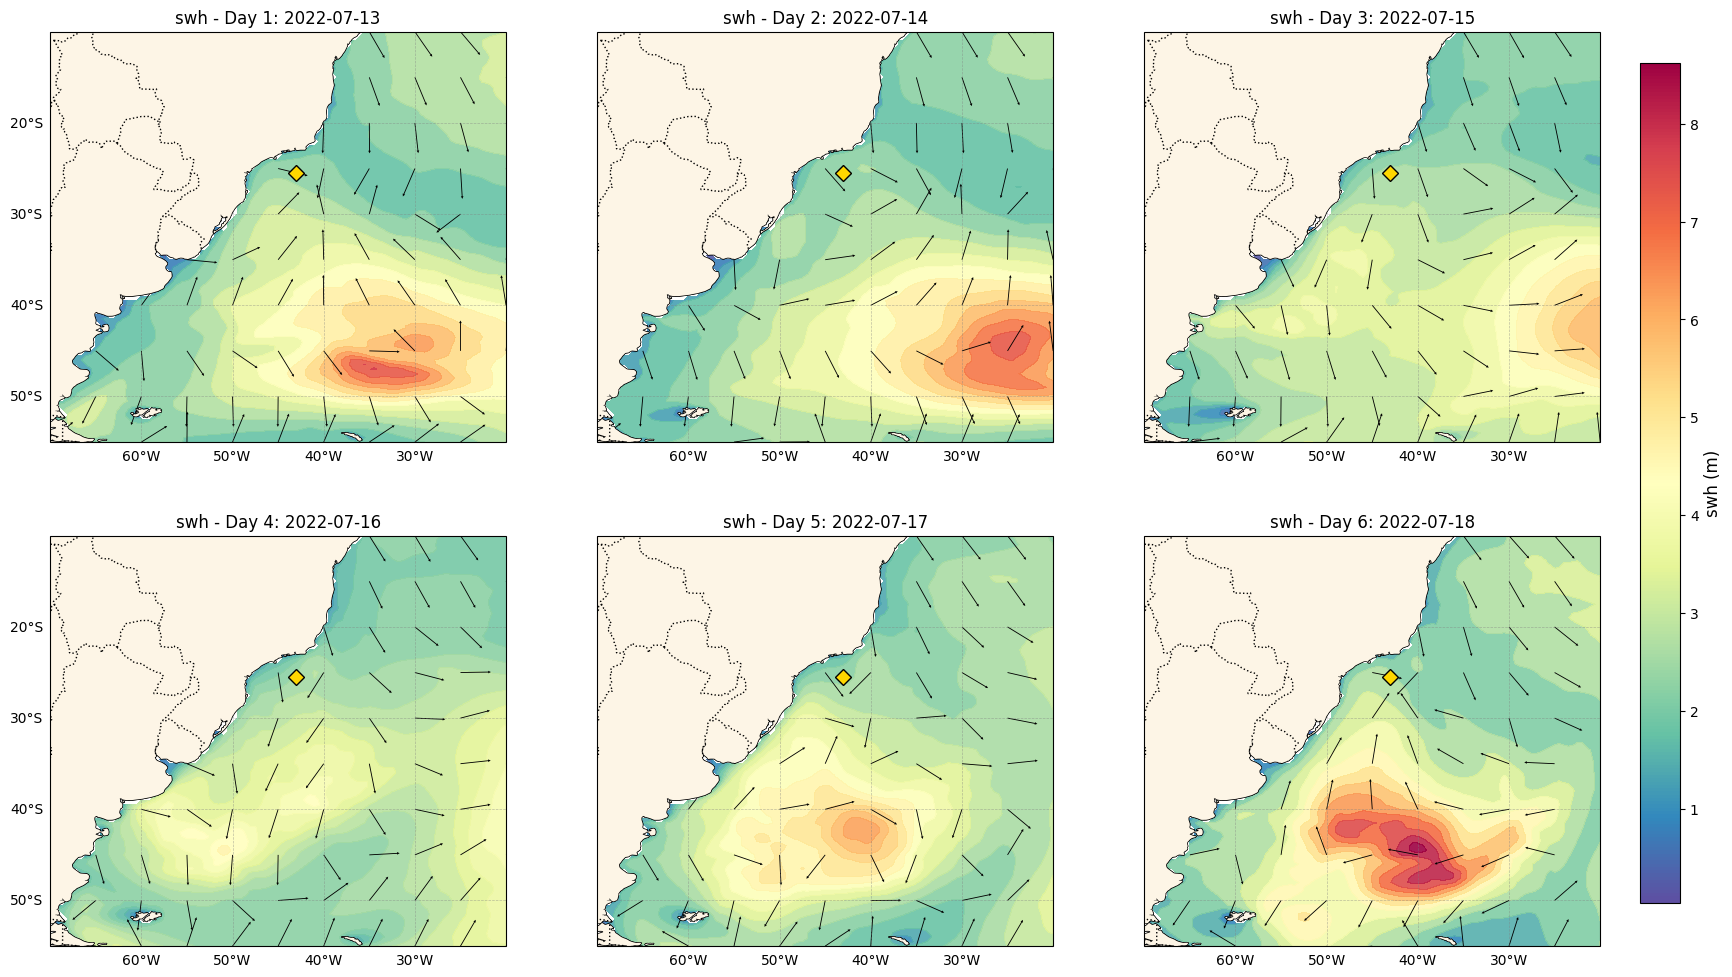

In [532]:
# Create a figure with subplots for each day
fig, axes = plt.subplots(2, 3, figsize=(20, 12), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

# Create a single colorbar for all plots with fixed range
norm = plt.Normalize(vmin=global_min, vmax=global_max)
sm = plt.cm.ScalarMappable(cmap='Spectral_r', norm=norm)
sm.set_array([])  # Empty array, we just need the colormap and normalization

# Loop through each day to plot the average current direction
for i, (day_data, day_label) in enumerate(zip(days, day_labels)):
    ax = axes[i]
    
    # Plot the mean current speed as a contour plot
    contour = ax.contourf(
        lon, lat, day_data.mean(dim='valid_time'),
        cmap= 'Spectral_r',
        transform=ccrs.PlateCarree(),
        norm=norm,  # Use the fixed normalization
        levels=15,
        alpha=0.9  # Set transparency for better visibility of quiver
    )
    
    # use wave direction to calculate uo and vo
    w_dir_rad = np.deg2rad(wave_ds['mwd'].sel(valid_time=slice(day_data.valid_time.values[0], day_data.valid_time.values[-1])).mean(dim='valid_time'))
    uo_mean = -np.cos(w_dir_rad) #* day_data.mean(dim='valid_time')
    vo_mean = -np.sin(w_dir_rad) #* day_data.mean(dim='valid_time')
    
    # Add quiver plot for current direction
    ax.quiver(
        lon[::10], lat[::10],  # Downsample for clarity
        uo_mean.values[::10, ::10],
        vo_mean.values[::10, ::10],
        transform=ccrs.PlateCarree(),
        color='black', scale=15, width=0.0019, headlength=3, headaxislength=3   # wave height: color='black', scale=120, width=0.003, headlength=3, headaxislength=3
    )                                                                           # e_flux: color='black', scale=15, width=0.0019, headlength=3, headaxislength=3
    
    # Add coastlines and gridlines
    ax.coastlines()
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False

    try:
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='black')
        ax.add_feature(cfeature.LAND, facecolor='oldlace', zorder=2)
        ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black', zorder=3)

    except ImportError:
        print("Cartopy não está instalado. Por favor, instale-o para adicionar a camada de vetor continental.")
    
    # Remove latitude labels for subplots 1, 2, 4, 5
    if i in [1,2,4,5]:  # Corresponds to subplots 1, 2, 4, 5 (0-indexed)
        gl.left_labels = False

    # Remove labels from subplots 0, 1, 2 (title, x-axis, y-axis labels)
    if i in [0, 1, 2]:
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_title(f'{day_label}', fontsize=10) # Keep only the date
    else:
        ax.set_title(f'{variable_name} - {day_label}', fontsize=12)


    # Mark the two points with colored circles
    ax.plot(
        centroid_point[0], centroid_point[1],
        'D',                    # Circle marker
        color='gold',          # point color  
        markersize=8,
        markeredgecolor='black',
        transform=ccrs.PlateCarree(),
        label='centroide',      #  Define label,
        alpha=1                 # set transparency
    )
    
    # Set title
    ax.set_title(f'{variable_name} - {day_label}', fontsize=12)

# Add a single vertical colorbar at the bottom center
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [deslocamento horizaontal, deslocamento vertical, width, height] 
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='vertical')
cbar.set_label(f'{variable_name} ({unit})', fontsize=12)
cbar.ax.tick_params(labelsize=10)  # Adjust colorbar tick label size

#save figure
plt.savefig(f"D:/SARC_LISA_2024/04_dados_finais/figuras_dns_maps/relevant_dates/{relevant_date.date()}_{variable_name}_maps_with_vectors_dns.png", dpi=300)

# Show the plot
plt.show()

## wave energy flux

In [533]:
dataset = wave_ds # wind_ds # wave_ds # current_ds # msl_ds
variable_name = 'e_flux'  # 'swh'  # wind_speed  # 'current_speed' # 'e_flux' # 'msl'
variable_label ='Wave Energy Flux (kW/m)'  # Significant Wave Height (m)  # Wind Speed (m/s)  # Current Speed (m/s) # 'Wave Energy Flux (kW/m)' # Mean Sea Level Pressure (hPa)
unit = 'kW/m'  # 'm'  # 'm/s'  # 'm/s' # 'kW/m' # 'hPa'

lat = dataset.latitude
lon = dataset.longitude

In [534]:
# separe data per day
day_01 = dataset[variable_name].sel(valid_time=slice(start_date, start_date + pd.Timedelta(days=1)))
day_02 = dataset[variable_name].sel(valid_time=slice(start_date + pd.Timedelta(days=1), start_date + pd.Timedelta(days=2)))
day_03 = dataset[variable_name].sel(valid_time=slice(start_date + pd.Timedelta(days=2), start_date + pd.Timedelta(days=3)))
day_04 = dataset[variable_name].sel(valid_time=slice(start_date + pd.Timedelta(days=3), start_date + pd.Timedelta(days=4)))
day_05 = dataset[variable_name].sel(valid_time=slice(start_date + pd.Timedelta(days=4), start_date + pd.Timedelta(days=5)))
day_06 = dataset[variable_name].sel(valid_time=slice(start_date + pd.Timedelta(days=5), start_date + pd.Timedelta(days=6)))

days = [day_01, day_02, day_03, day_04, day_05,day_06]

day_labels = [
    f"Day 1: {start_date.date()}",
    f"Day 2: {(start_date + pd.Timedelta(days=1)).date()}",
    f"Day 3: {(start_date + pd.Timedelta(days=2)).date()}",
    f"Day 4: {(start_date + pd.Timedelta(days=3)).date()}",
    f"Day 5: {(start_date + pd.Timedelta(days=4)).date()}",
    f"Day 6: {(start_date + pd.Timedelta(days=5)).date()}"
]

# find the overall min and max for consistent color scale
all_days_data = [day.mean(dim = 'valid_time') for day in days]
global_min = np.nanmin([np.nanmin(day_data.values) for day_data in all_days_data])
global_max = np.nanmax([np.nanmax(day_data.values) for day_data in all_days_data])

C:\Users\locfa\AppData\Local\Temp\ipykernel_18580\1986989360.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


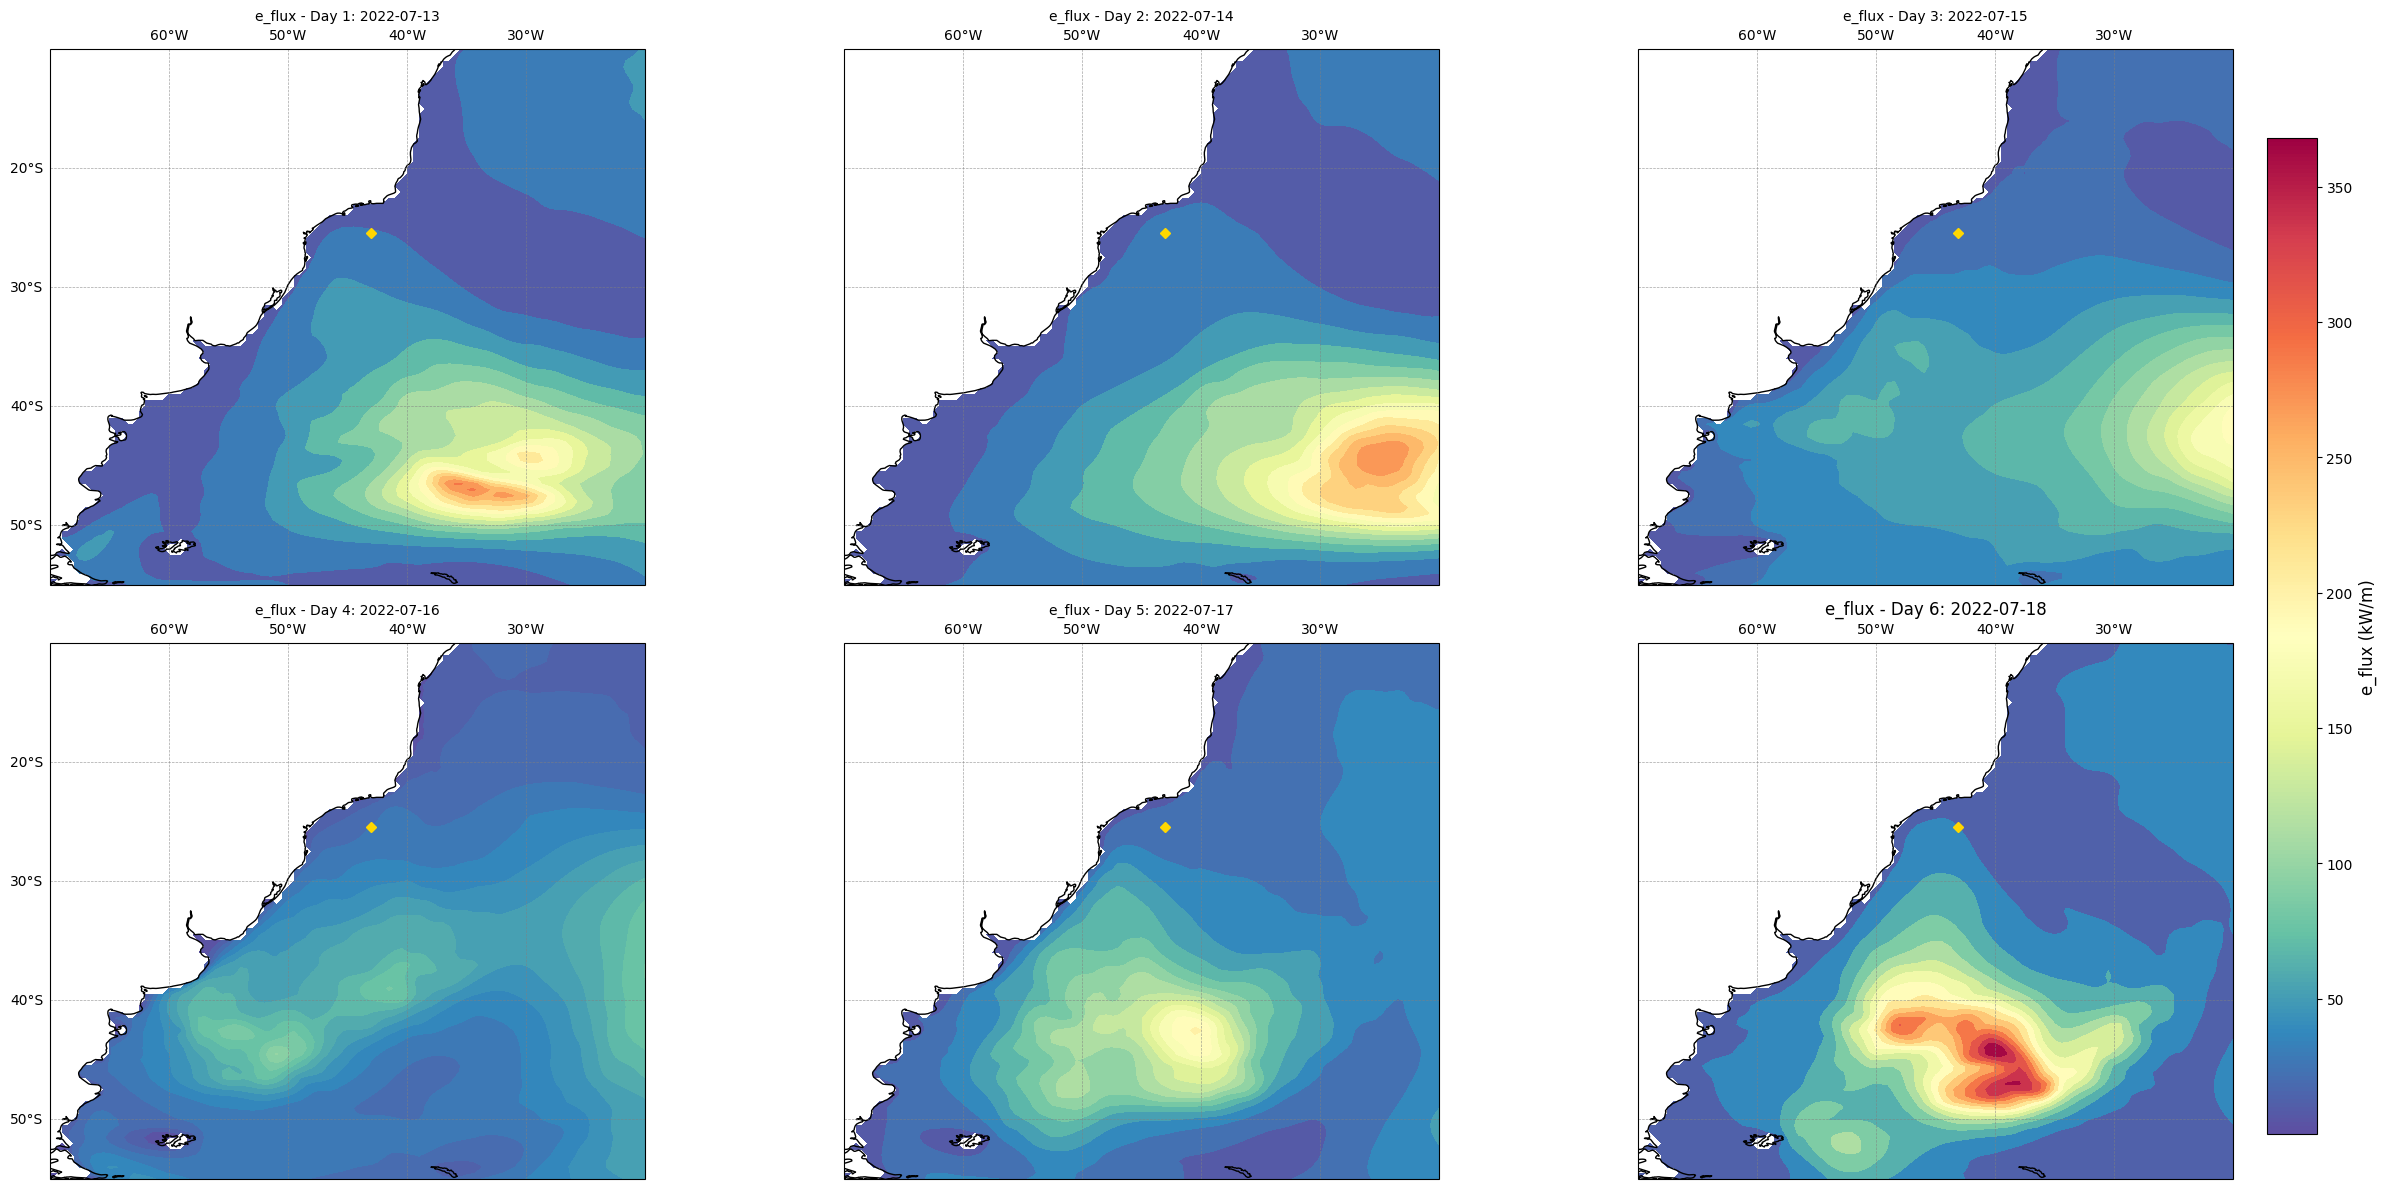

In [535]:

# --- Create figure with consistent color scaling ---
fig = plt.figure(figsize=(25, 12))  # Slightly taller figure to accommodate colorbar
axes = []

# Create a single colorbar for all plots with fixed range
norm = plt.Normalize(vmin=global_min, vmax=global_max)
sm = plt.cm.ScalarMappable(cmap='Spectral_r', norm=norm)
sm.set_array([])  # Empty array, we just need the colormap and normalization

for i in range(len(days)):
    ax = fig.add_subplot(2, 3, i+1, projection=ccrs.PlateCarree())
    axes.append(ax)

# Create a list to store all contour objects for colorbar
contours = []

for i, (day_data, day_label) in enumerate(zip(days, day_labels)):
    # --- Contour plot with fixed color range ---
    contour = axes[i].contourf(
        lon, lat, day_data.mean(dim='valid_time'), 
        cmap='Spectral_r', 
        transform=ccrs.PlateCarree(),
        norm=norm,  # Use the fixed normalization
        levels=15,
        # alpha = 0.9
    )

    contours.append(contour)  # Store contour for colorbar reference

    # --- Coastlines and gridlines ---
    axes[i].coastlines()
    gl = axes[i].gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.7, linestyle='--')
    gl.top_labels = True
    gl.left_labels = True
    gl.right_labels = False
    gl.bottom_labels = False
    

    axes[i].plot(
        centroid_point[0], centroid_point[1],
        'D',
        color = 'gold',
        markersize=5,
        transform=ccrs.PlateCarree(),
        label='Centro da área de interesse'  # 'Centro da área de interesse'
    )
    
    # --- Labels and title ---
    axes[i].set_xlabel('Longitude')
    axes[i].set_ylabel('Latitude')
    axes[i].set_title(f'{variable_name} - {day_label}', fontsize=10)

    # Remove latitude labels for subplots 1, 2, 4, 5
    if i in [1,2,4,5]:  # Corresponds to subplots 1, 2, 4, 5 (0-indexed)
        gl.left_labels = False

    # Remove labels from subplots 0, 1, 2 (title, x-axis, y-axis labels)
    if i in [0, 1, 2]:
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_title(f'{day_label}', fontsize=10) # Keep only the date
    else:
        ax.set_title(f'{variable_name} - {day_label}', fontsize=12)


# Add a single vertical colorbar at the bottom center
cbar_ax = fig.add_axes([0.95, 0.05, 0.02, 0.83])  # [deslocamento horizaontal, deslocamento vertical, width, height] 
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='vertical')
cbar.set_label(f'{variable_name} ({unit})', fontsize=12)
cbar.ax.tick_params(labelsize=10)  # Adjust colorbar tick label size

# Adjust layout to make space for the colorbar at the bottom
plt.tight_layout()
# plt.subplots_adjust(bottom=0.05)  # Make extra space at the bottom

plt.savefig(f"D:/SARC_LISA_2024/04_dados_finais/figuras_dns_maps/relevant_dates/{relevant_date.date()}_{variable_name}_maps_dns.png", dpi=300)
# Show the plot
plt.show()

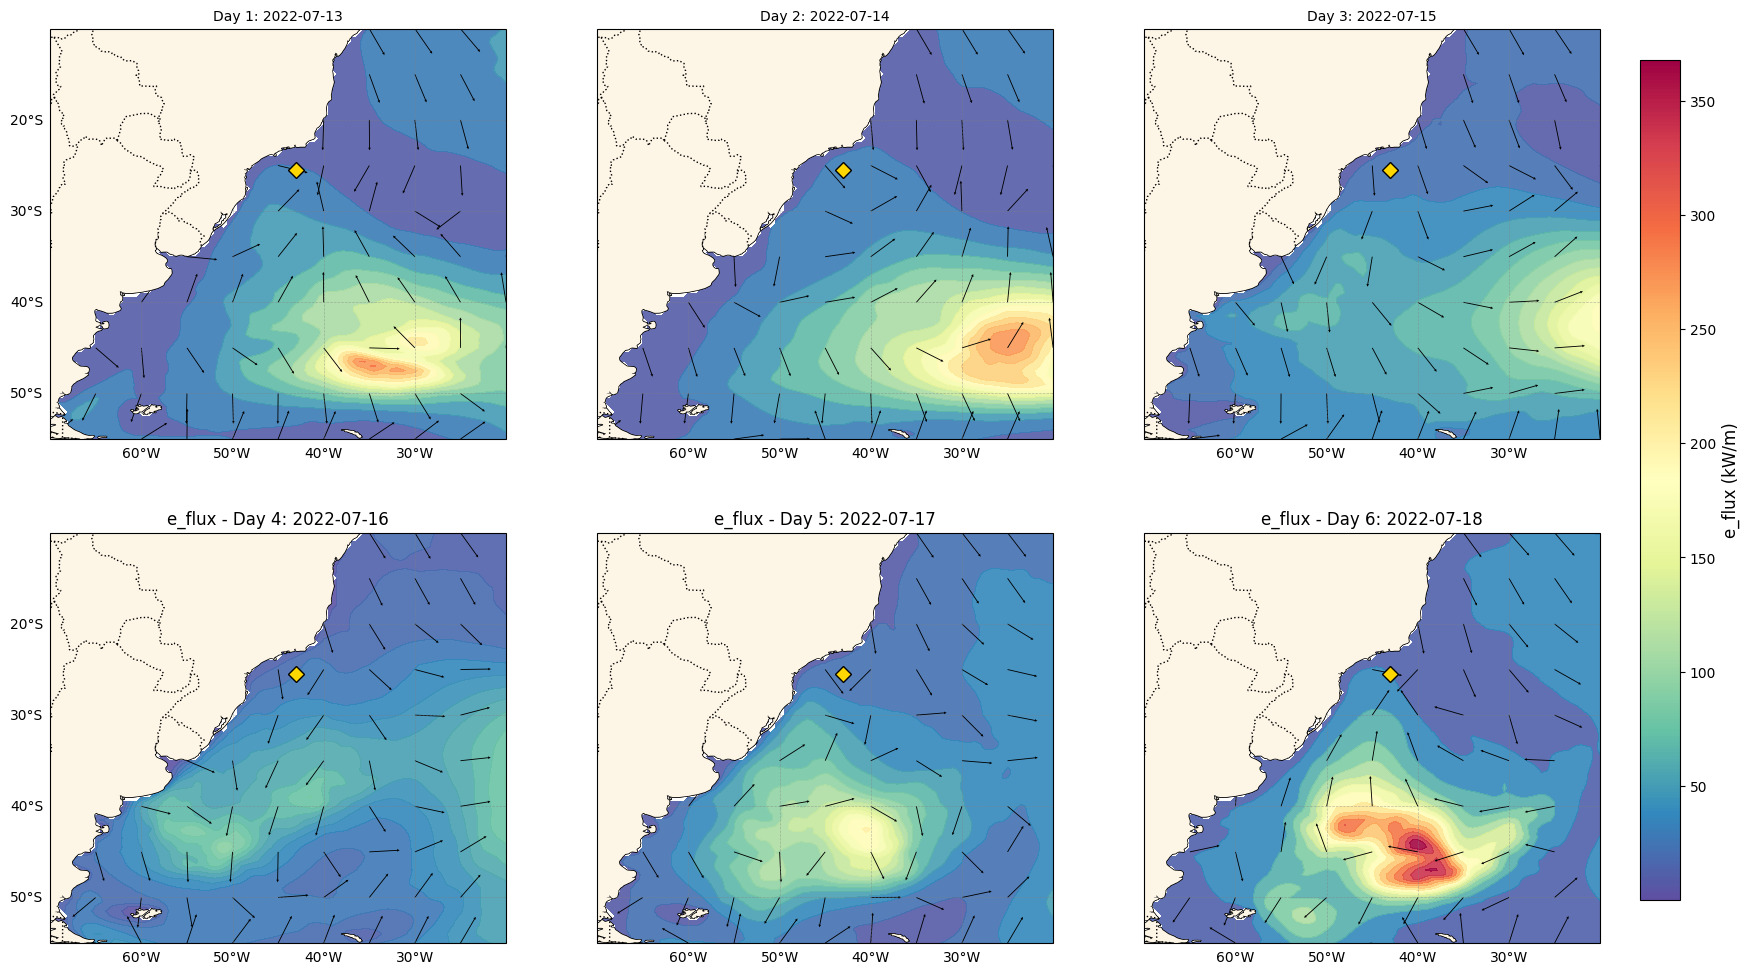

In [536]:
# Create a figure with subplots for each day
fig, axes = plt.subplots(2, 3, figsize=(20, 12), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

# Create a single colorbar for all plots with fixed range
norm = plt.Normalize(vmin=global_min, vmax=global_max)
sm = plt.cm.ScalarMappable(cmap='Spectral_r', norm=norm)
sm.set_array([])  # Empty array, we just need the colormap and normalization

contours = []
# Loop through each day to plot the average current direction
for i, (day_data, day_label) in enumerate(zip(days, day_labels)):
    ax = axes[i]
    
    # Plot the mean current speed as a contour plot
    contour = ax.contourf(
        lon, lat, day_data.mean(dim='valid_time'),
        cmap='Spectral_r',
        transform=ccrs.PlateCarree(),
        norm=norm,  # Use the fixed normalization
        levels=15,
        alpha=0.9  # Set transparency for better visibility of quiver
    )
    
    contours.append(contour)

    # use wave direction to calculate uo and vo
    w_dir_rad = np.deg2rad(wave_ds['mwd'].sel(valid_time=slice(day_data.valid_time.values[0], day_data.valid_time.values[-1])).mean(dim='valid_time'))
    uo_mean = -np.cos(w_dir_rad) #* day_data.mean(dim='valid_time')
    vo_mean = -np.sin(w_dir_rad) #* day_data.mean(dim='valid_time')
    
    # Add quiver plot for current direction
    ax.quiver(
        lon[::10], lat[::10],  # Downsample for clarity
        uo_mean.values[::10, ::10],
        vo_mean.values[::10, ::10],
        transform=ccrs.PlateCarree(),
        color='black', scale=15, width=0.0019, headlength=3, headaxislength=3
    )
    
    # Add coastlines and gridlines
    ax.coastlines()
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False

    try:
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='black')
        ax.add_feature(cfeature.LAND, facecolor='oldlace', zorder=2)
        ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black', zorder=3)
    except ImportError:
        print("Cartopy não está instalado. Por favor, instale-o para adicionar a camada de vetor continental.")
    
    # Remove latitude labels for subplots 1, 2, 4, 5
    if i in [1,2,4,5]:  # Corresponds to subplots 1, 2, 4, 5 (0-indexed)
        gl.left_labels = False

    # Remove labels from subplots 0, 1, 2 (title, x-axis, y-axis labels)
    if i in [0, 1, 2]:
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_title(f'{day_label}', fontsize=10) # Keep only the date
    else:
        ax.set_title(f'{variable_name} - {day_label}', fontsize=12)

    # Mark the two points with colored circles
    ax.plot(
        centroid_point[0], centroid_point[1],
        'D',                    # Circle marker
        color='gold',          # point color  
        markersize=8,
        markeredgecolor='black',
        transform=ccrs.PlateCarree(),
        label='centroide',      #  Define label,
        alpha=1                 # set transparency
    )

# Add a single vertical colorbar using the ScalarMappable with global range
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [deslocamento horizaontal, deslocamento vertical, width, height] 
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='vertical')
cbar.set_label(f'{variable_name} ({unit})', fontsize=12)
cbar.ax.tick_params(labelsize=10)  # Adjust colorbar tick label size

#save figure
plt.savefig(f"D:/SARC_LISA_2024/04_dados_finais/figuras_dns_maps/relevant_dates/{relevant_date.date()}_{variable_name}_maps_with_vectors_dns.png", dpi=300)

# Show the plot
plt.show()

## wind dataset

In [537]:
# load wind dataset
wind_ds = xr.open_dataset(f"D:/SARC_LISA_2024/01_dados_brutos/dados_de_reanalise/02_parametros_fisicos/ERA5_2016_2023/wind_parameters_2016_2024/wind_ERA5_{year}.nc").sel(valid_time=slice(start_date, end_date))

wind_ds['wind_speed'] = np.sqrt(wind_ds['u10']**2 + wind_ds['v10']**2)  
wind_ds['wind_direction'] = (270 - np.degrees(np.arctan2(wind_ds['v10'], wind_ds['u10']))) % 360

wind_ds = wind_ds.rename({'u10': 'uo', 'v10': 'vo'})

In [538]:
dataset = wind_ds # wind_ds # wave_ds # current_ds # msl_ds
variable_name = 'wind_speed'  # 'swh'  # wind_speed  # 'current_speed' # 'e_flux' # 'msl'
variable_label ='Wind Speed (m/s)'  # Significant Wave Height (m)  # Wind Speed (m/s)  # Current Speed (m/s) # 'Wave Energy Flux (kW/m)' # Mean Sea Level Pressure (hPa)
unit = 'm/s'  # 'm'  # 'm/s'  # 'm/s' # 'kW/m' # 'hPa'

In [539]:
# only for wind and current datasets 
uo = dataset['uo']
vo = dataset['vo']

lat = dataset.latitude
lon = dataset.longitude

In [540]:
# separe data per day
day_01 = dataset[variable_name].sel(valid_time=slice(start_date, start_date + pd.Timedelta(days=1)))
day_02 = dataset[variable_name].sel(valid_time=slice(start_date + pd.Timedelta(days=1), start_date + pd.Timedelta(days=2)))
day_03 = dataset[variable_name].sel(valid_time=slice(start_date + pd.Timedelta(days=2), start_date + pd.Timedelta(days=3)))
day_04 = dataset[variable_name].sel(valid_time=slice(start_date + pd.Timedelta(days=3), start_date + pd.Timedelta(days=4)))
day_05 = dataset[variable_name].sel(valid_time=slice(start_date + pd.Timedelta(days=4), start_date + pd.Timedelta(days=5)))
day_06 = dataset[variable_name].sel(valid_time=slice(start_date + pd.Timedelta(days=5), start_date + pd.Timedelta(days=6)))


days = [day_01, day_02, day_03, day_04, day_05,day_06]

day_labels = [
    f"Day 1: {start_date.date()}",
    f"Day 2: {(start_date + pd.Timedelta(days=1)).date()}",
    f"Day 3: {(start_date + pd.Timedelta(days=2)).date()}",
    f"Day 4: {(start_date + pd.Timedelta(days=3)).date()}",
    f"Day 5: {(start_date + pd.Timedelta(days=4)).date()}",
    f"Day 6: {(start_date + pd.Timedelta(days=5)).date()}"
]

# find the overall min and max for consistent color scale
all_days_data = [day.mean(dim = 'valid_time') for day in days]
global_min = np.nanmin([np.nanmin(day_data.values) for day_data in all_days_data])
global_max = np.nanmax([np.nanmax(day_data.values) for day_data in all_days_data])


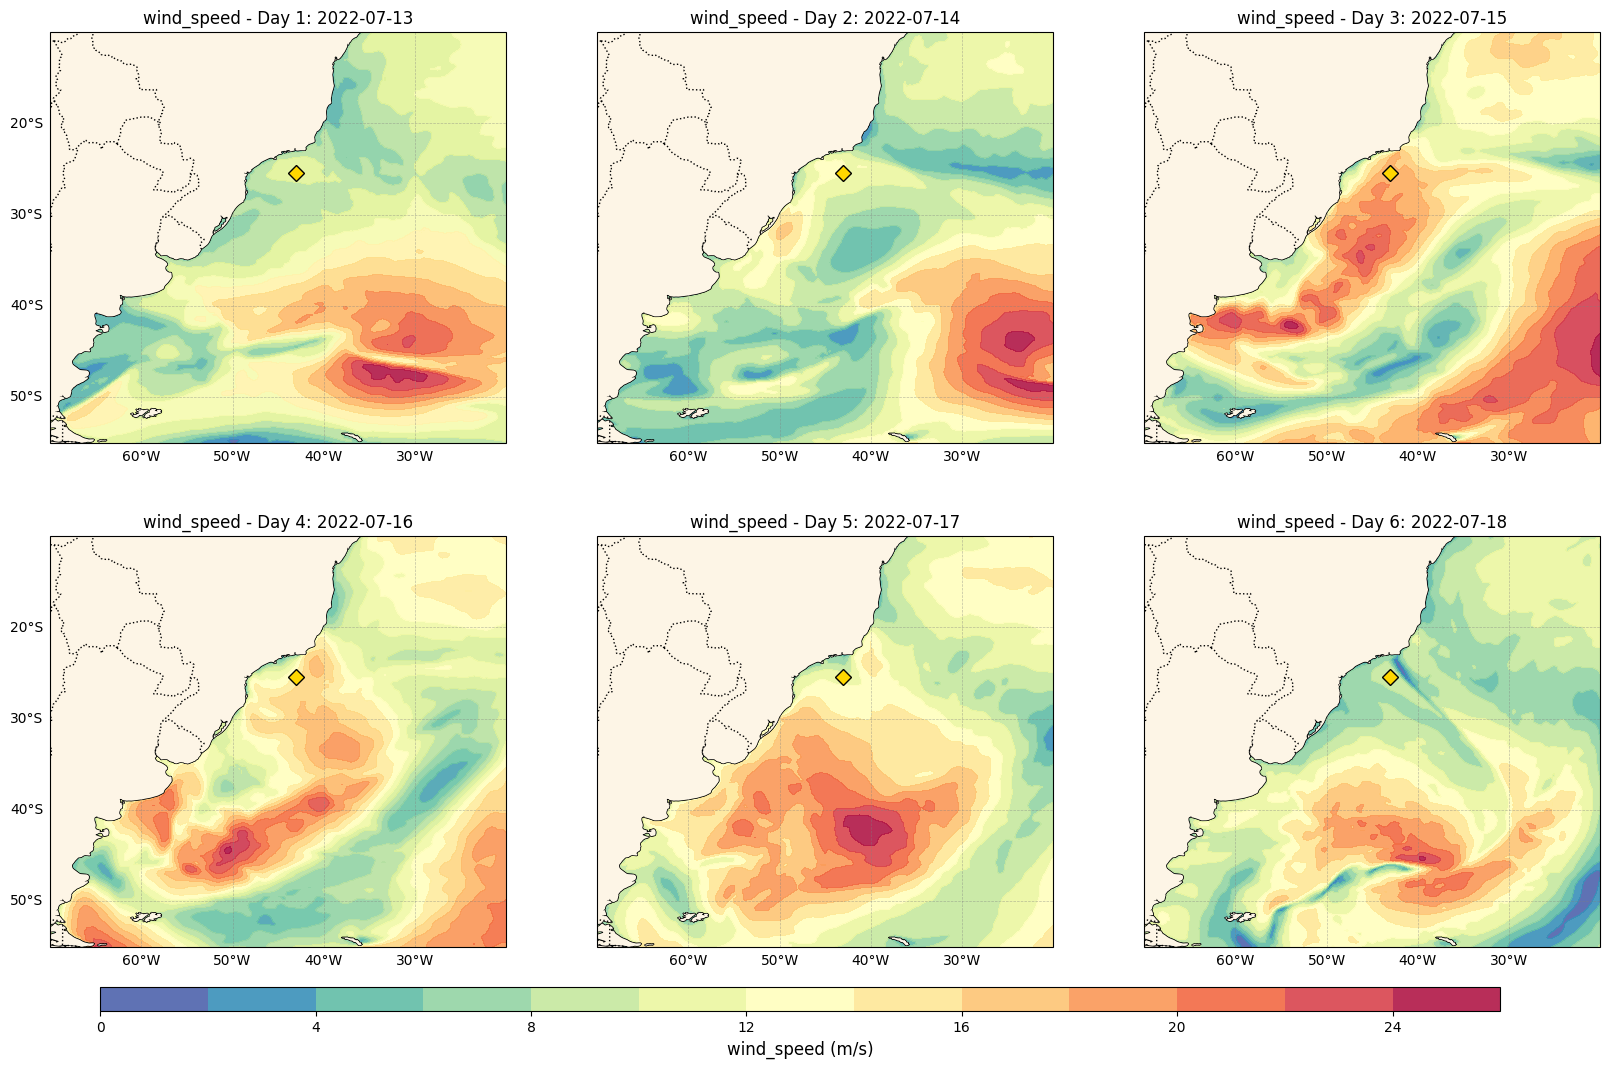

In [541]:
# Create a figure with subplots for each day
fig, axes = plt.subplots(2, 3, figsize=(20, 12), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

# Loop through each day to plot the average current direction
for i, (day_data, day_label) in enumerate(zip(days, day_labels)):
    ax = axes[i]
    
    # Plot the mean current speed as a contour plot
    contour = ax.contourf(
        lon, lat, day_data.mean(dim='valid_time'),
        cmap= 'Spectral_r',
        transform=ccrs.PlateCarree(),
        levels=15,
        alpha=0.9  # Set transparency for better visibility of quiver
    )
    
    # Calculate the mean uo and vo for the day
    uo_mean = uo.sel(valid_time=slice(day_data.valid_time.values[0], day_data.valid_time.values[-1])).mean(dim='valid_time')
    vo_mean = vo.sel(valid_time=slice(day_data.valid_time.values[0], day_data.valid_time.values[-1])).mean(dim='valid_time')
    
    # # Add quiver plot for current direction
    # ax.quiver(
    #     lon[::15], lat[::15],  # Downsample for clarity
    #     uo_mean.values[::15, ::15], vo_mean.values[::15, ::15],
    #     transform=ccrs.PlateCarree(),
    #     color='black', scale=120, width=0.003, headlength=3, headaxislength=4
    #     # for wind data: color='black', scale=90, width=0.003, headlength=3, headaxislength=4
    # )
    
    # Add coastlines and gridlines
    ax.coastlines()
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False

    try:
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='black')
        ax.add_feature(cfeature.LAND, facecolor='oldlace', zorder=2)
        ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black', zorder=3)

    except ImportError:
        print("Cartopy não está instalado. Por favor, instale-o para adicionar a camada de vetor continental.")
    
    # Remove latitude labels for subplots 1, 2, 4, 5
    if i in [1,2,4,5]:  # Corresponds to subplots 1, 2, 4, 5 (0-indexed)
        gl.left_labels = False

    # Remove labels from subplots 0, 1, 2 (title, x-axis, y-axis labels)
    if i in [0, 1, 2]:
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_title(f'{day_label}', fontsize=10) # Keep only the date
    else:
        ax.set_title(f'{variable_name} - {day_label}', fontsize=12)


    # Mark the point with colored circles
    ax.plot(
        centroid_point[0], centroid_point[1],
        'D',                    # Circle marker
        color='gold',          # point color  
        markersize=8,
        markeredgecolor='black',
        transform=ccrs.PlateCarree(),
        label='centroide',      #  Define label,
        alpha=1                 # set transparency
    )
    
    # Set title
    ax.set_title(f'{variable_name} - {day_label}', fontsize=12)

# Adjust layout and add a colorbar
# plt.tight_layout()
cbar_ax = fig.add_axes([0.15, 0.06, 0.7, 0.02])  # [left, bottom, width, height]
# for current data: [0.15, 0.09, 0.7, 0.02]
# for wind data: [0.15, -0.025, 0.7, 0.02]

cbar = fig.colorbar(contour, cax=cbar_ax, orientation='horizontal')
cbar.set_label(f'{variable_name} ({unit})', fontsize=12)

#save figure
plt.savefig(f"D:/SARC_LISA_2024/04_dados_finais/figuras_dns_maps/relevant_dates/{relevant_date.date()}_{variable_name}_maps_dns.png", dpi=300)

# Show the plot
plt.show()

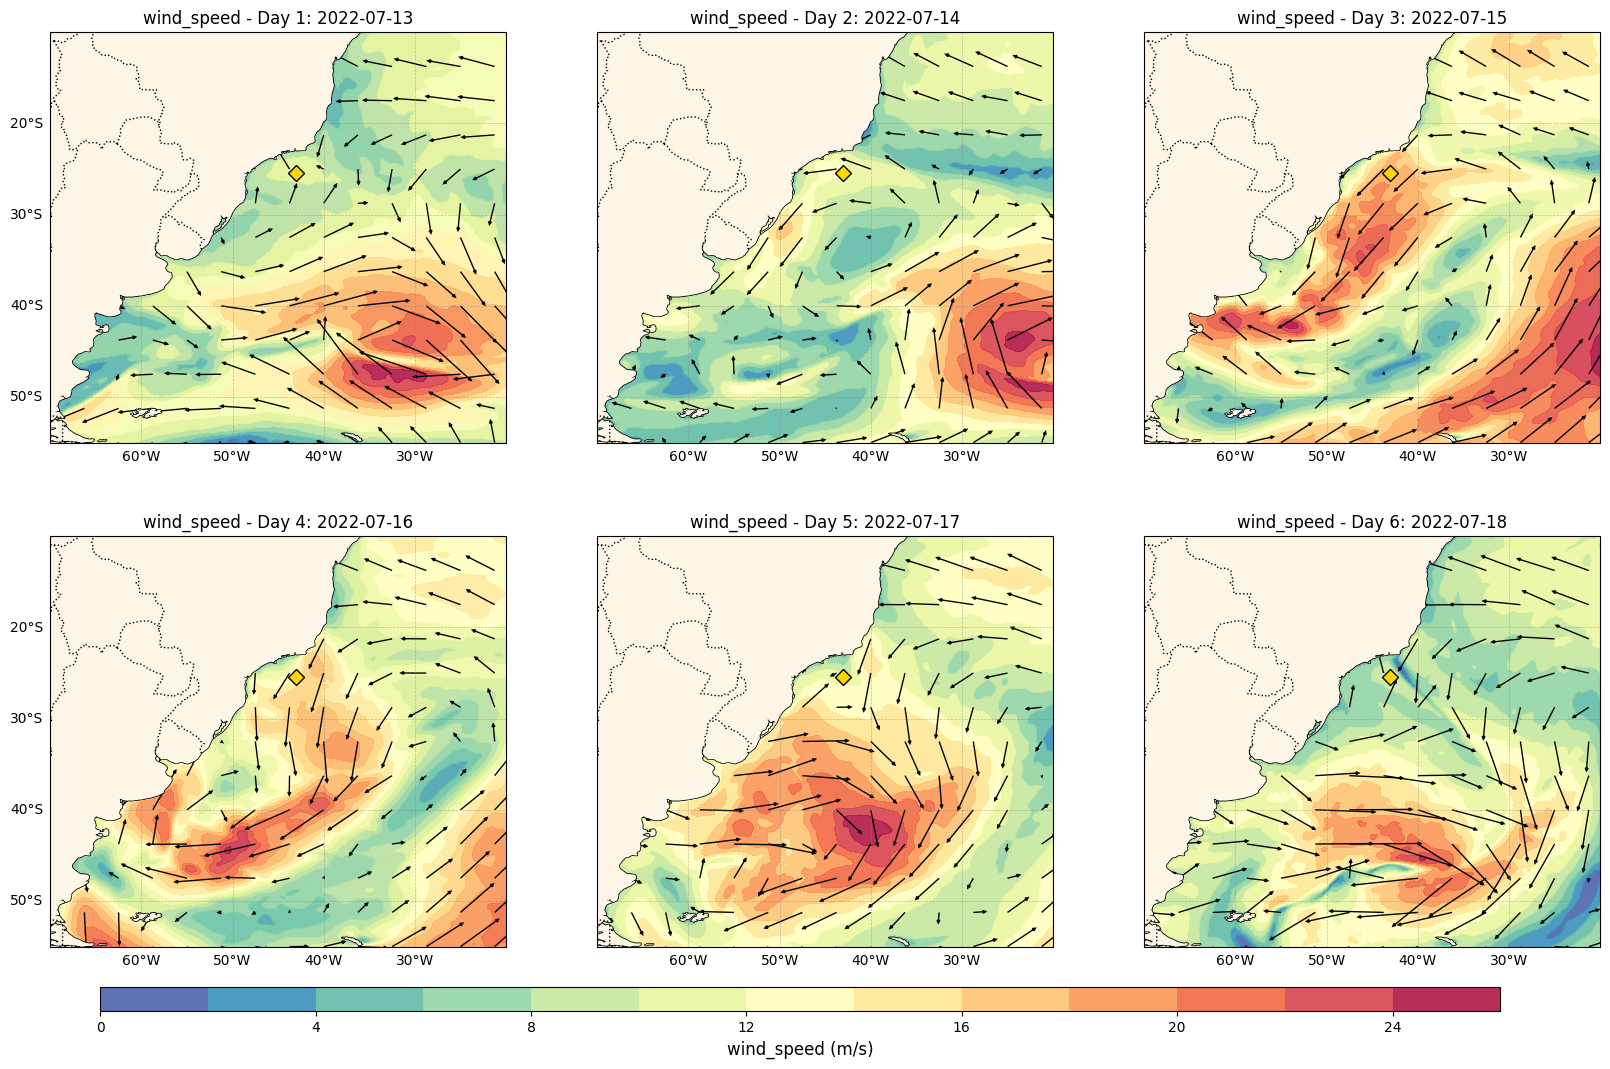

In [542]:
# Create a figure with subplots for each day
fig, axes = plt.subplots(2, 3, figsize=(20, 12), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

# Loop through each day to plot the average current direction
for i, (day_data, day_label) in enumerate(zip(days, day_labels)):
    ax = axes[i]
    
    # Plot the mean current speed as a contour plot
    contour = ax.contourf(
        lon, lat, day_data.mean(dim='valid_time'),
        cmap= 'Spectral_r',
        transform=ccrs.PlateCarree(),
        levels=15,
        alpha=0.9  # Set transparency for better visibility of quiver
    )
    
    # Calculate the mean uo and vo for the day
    uo_mean = uo.sel(valid_time=slice(day_data.valid_time.values[0], day_data.valid_time.values[-1])).mean(dim='valid_time')
    vo_mean = vo.sel(valid_time=slice(day_data.valid_time.values[0], day_data.valid_time.values[-1])).mean(dim='valid_time')
    
    # Add quiver plot for current direction
    ax.quiver(
        lon[::15], lat[::15],  # Downsample for clarity
        uo_mean.values[::15, ::15], vo_mean.values[::15, ::15],
        transform=ccrs.PlateCarree(),
        color='black', scale=120, width=0.003, headlength=3, headaxislength=4
        # for wind data: color='black', scale=90, width=0.003, headlength=3, headaxislength=4
    )
    
    # Add coastlines and gridlines
    ax.coastlines()
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False

    try:
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='black')
        ax.add_feature(cfeature.LAND, facecolor='oldlace', zorder=2)
        ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black', zorder=3)

    except ImportError:
        print("Cartopy não está instalado. Por favor, instale-o para adicionar a camada de vetor continental.")
    
    # Remove latitude labels for subplots 1, 2, 4, 5
    if i in [1,2,4,5]:  # Corresponds to subplots 1, 2, 4, 5 (0-indexed)
        gl.left_labels = False

    # Remove labels from subplots 0, 1, 2 (title, x-axis, y-axis labels)
    if i in [0, 1, 2]:
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_title(f'{day_label}', fontsize=10) # Keep only the date
    else:
        ax.set_title(f'{variable_name} - {day_label}', fontsize=12)


    # Mark the two points with colored circles
    ax.plot(
        centroid_point[0], centroid_point[1],
        'D',                    # Circle marker
        color='gold',          # point color  
        markersize=8,
        markeredgecolor='black',
        transform=ccrs.PlateCarree(),
        label='centroide',      #  Define label,
        alpha=1                 # set transparency
    )
    
    # Set title
    ax.set_title(f'{variable_name} - {day_label}', fontsize=12)

# Adjust layout and add a colorbar
# plt.tight_layout()
cbar_ax = fig.add_axes([0.15, 0.06, 0.7, 0.02])  # [left, bottom, width, height]
cbar = fig.colorbar(contour, cax=cbar_ax, orientation='horizontal')
cbar.set_label(f'{variable_name} ({unit})', fontsize=12)

#save figure
plt.savefig(f"D:/SARC_LISA_2024/04_dados_finais/figuras_dns_maps/relevant_dates/{relevant_date.date()}_{variable_name}_maps_with_vectors_dns.png", dpi=300)

# Show the plot
plt.show()

## current dataset

In [543]:
# load current dataset
current_ds = (
    xr.open_dataset("D:/SARC_LISA_2024/01_dados_brutos/dados_de_reanalise/02_parametros_fisicos/corrente_waverys_AS_1979_2024/glorys_sarc.nc")
    .sel(time=slice(datetime(2016, 1, 1), datetime(2024, 12, 31)))
    # .sel(latitude= lat, longitude=lon, method='nearest')
    .sel(depth=9, method='nearest')
)
# remove thetao variable from current dataset
current_ds = current_ds.drop_vars("thetao")

# calculate current speed and direction
current_ds['current_speed'] = np.sqrt(current_ds.uo**2 + current_ds.vo**2)
current_ds['c_direction'] = (90 - np.degrees(np.arctan2(current_ds.vo, current_ds.uo))) % 360

uo = current_ds['uo']
vo = current_ds['vo']

# change time coordinate name to valid_time for consistency
current_ds = current_ds.rename({'time': 'valid_time'})

In [544]:
dataset = current_ds # wind_ds # wave_ds # current_ds # msl_ds
variable_name = 'current_speed'  # 'swh'  # wind_speed  # 'current_speed' # 'e_flux' # 'msl'
variable_label ='Current Speed (m/s)'  # Significant Wave Height (m)  # Wind Speed (m/s)  # Current Speed (m/s) # 'Wave Energy Flux (kW/m)' # Mean Sea Level Pressure (hPa)
unit = 'm/s'  # 'm'  # 'm/s'  # 'm/s' # 'kW/m' # 'hPa'

In [545]:
# only for wind and current datasets 
uo = dataset['uo']
vo = dataset['vo']

lat = dataset.latitude
lon = dataset.longitude

In [546]:
# separe data per day
day_01 = dataset[variable_name].sel(valid_time=slice(start_date, start_date + pd.Timedelta(days=1)))
day_02 = dataset[variable_name].sel(valid_time=slice(start_date + pd.Timedelta(days=1), start_date + pd.Timedelta(days=2)))
day_03 = dataset[variable_name].sel(valid_time=slice(start_date + pd.Timedelta(days=2), start_date + pd.Timedelta(days=3)))
day_04 = dataset[variable_name].sel(valid_time=slice(start_date + pd.Timedelta(days=3), start_date + pd.Timedelta(days=4)))
day_05 = dataset[variable_name].sel(valid_time=slice(start_date + pd.Timedelta(days=4), start_date + pd.Timedelta(days=5)))
day_06 = dataset[variable_name].sel(valid_time=slice(start_date + pd.Timedelta(days=5), start_date + pd.Timedelta(days=6)))


days = [day_01, day_02, day_03, day_04, day_05,day_06]

day_labels = [
    f"Day 1: {start_date.date()}",
    f"Day 2: {(start_date + pd.Timedelta(days=1)).date()}",
    f"Day 3: {(start_date + pd.Timedelta(days=2)).date()}",
    f"Day 4: {(start_date + pd.Timedelta(days=3)).date()}",
    f"Day 5: {(start_date + pd.Timedelta(days=4)).date()}",
    f"Day 6: {(start_date + pd.Timedelta(days=5)).date()}"
]

# find the overall min and max for consistent color scale
all_days_data = [day.mean(dim = 'valid_time') for day in days]
global_min = np.nanmin([np.nanmin(day_data.values) for day_data in all_days_data])
global_max = np.nanmax([np.nanmax(day_data.values) for day_data in all_days_data])


C:\Users\locfa\AppData\Local\Temp\ipykernel_18580\3928950466.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


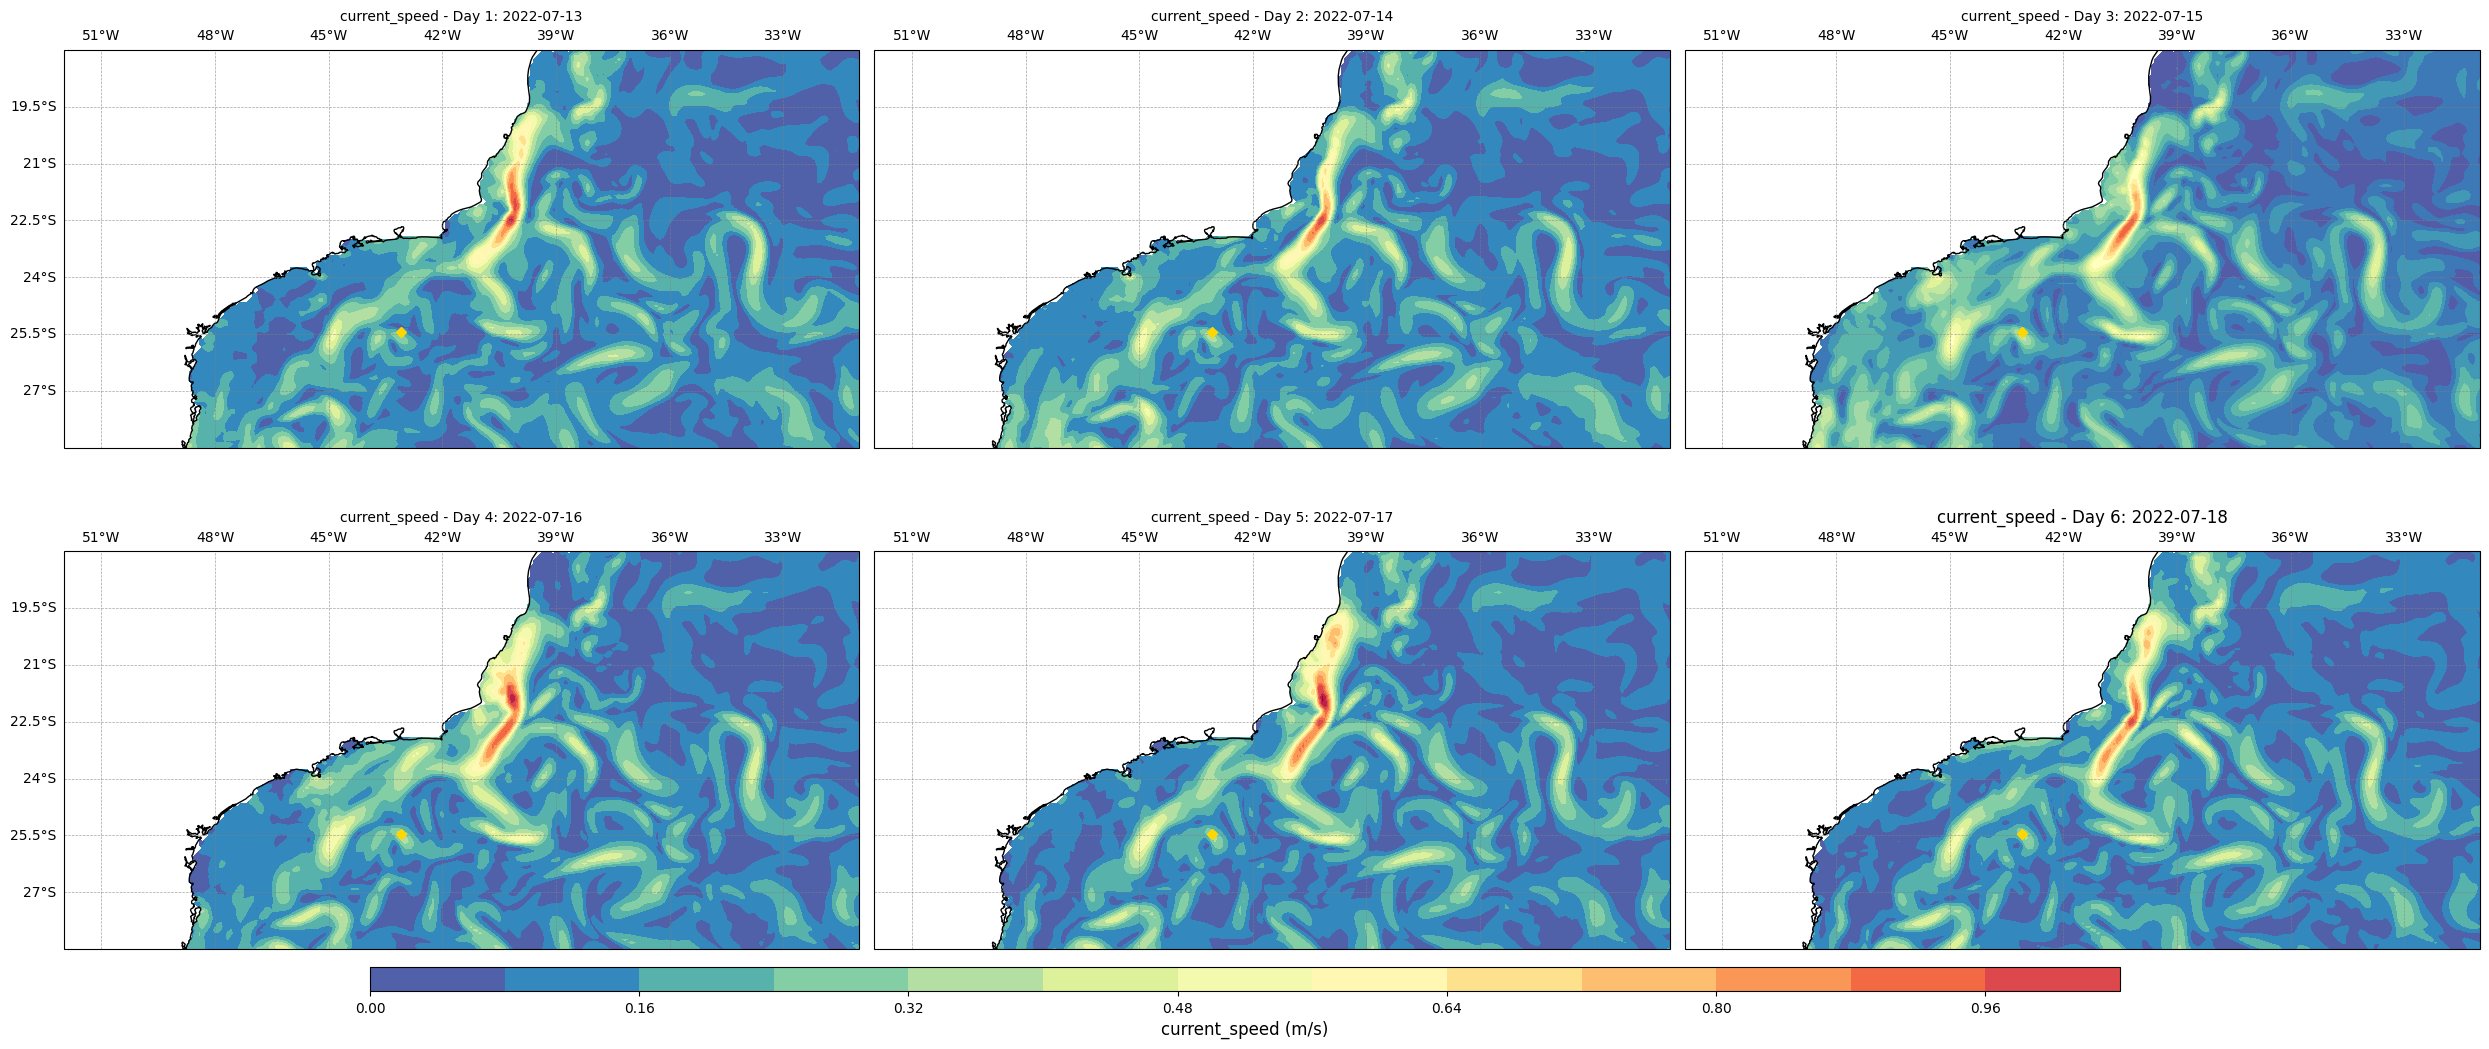

In [547]:

# --- Create figure with consistent color scaling ---
fig = plt.figure(figsize=(25, 12))  # Slightly taller figure to accommodate colorbar
axes = []

# Create a single colorbar for all plots with fixed range
norm = plt.Normalize(vmin= global_min, vmax= global_max)  # Adjust the vmin and vmax as needed

for i in range(len(days)):
    ax = fig.add_subplot(2, 3, i+1, projection=ccrs.PlateCarree())
    axes.append(ax)

for i, (day_data, day_label) in enumerate(zip(days, day_labels)):
    # --- Contour plot with fixed color range ---
    contour = axes[i].contourf(
        lon, lat, day_data.mean(dim='valid_time'), 
        cmap='Spectral_r', 
        transform=ccrs.PlateCarree(),
        norm=norm,  # Use the fixed normalization
        levels=15,
        # alpha = 0.9
    )

    # --- Coastlines and gridlines ---
    axes[i].coastlines()
    gl = axes[i].gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.7, linestyle='--')
    gl.top_labels = True
    gl.left_labels = True
    gl.right_labels = False
    gl.bottom_labels = False
    

    axes[i].plot(
        centroid_point[0], centroid_point[1],
        'D',
        color = 'gold',
        markersize=5,
        transform=ccrs.PlateCarree(),
        label='Centro da área de interesse'  # 'Centro da área de interesse'
    )
    
    # --- Labels and title ---
    axes[i].set_xlabel('Longitude')
    axes[i].set_ylabel('Latitude')
    axes[i].set_title(f'{variable_name} - {day_label}', fontsize=10)

    # Remove latitude labels for subplots 1, 2, 4, 5
    if i in [1,2,4,5]:  # Corresponds to subplots 1, 2, 4, 5 (0-indexed)
        gl.left_labels = False

    # Remove labels from subplots 0, 1, 2 (title, x-axis, y-axis labels)
    if i in [0, 1, 2]:
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_title(f'{day_label}', fontsize=10) # Keep only the date
    else:
        ax.set_title(f'{variable_name} - {day_label}', fontsize=12)


# Adjust layout and add a colorbar
plt.tight_layout()
cbar_ax = fig.add_axes([0.15, 0.09, 0.7, 0.02])  # [left, bottom, width, height]
cbar = fig.colorbar(contour, cax=cbar_ax, orientation='horizontal')
cbar.set_label(f'{variable_name} ({unit})', fontsize=12)

# Adjust layout to make space for the colorbar at the bottom
plt.tight_layout()
# plt.subplots_adjust(bottom=0.05)  # Make extra space at the bottom

plt.savefig(f"D:/SARC_LISA_2024/04_dados_finais/figuras_dns_maps/relevant_dates/{relevant_date.date()}_{variable_name}_maps_dns.png", dpi=300)
# Show the plot
plt.show()

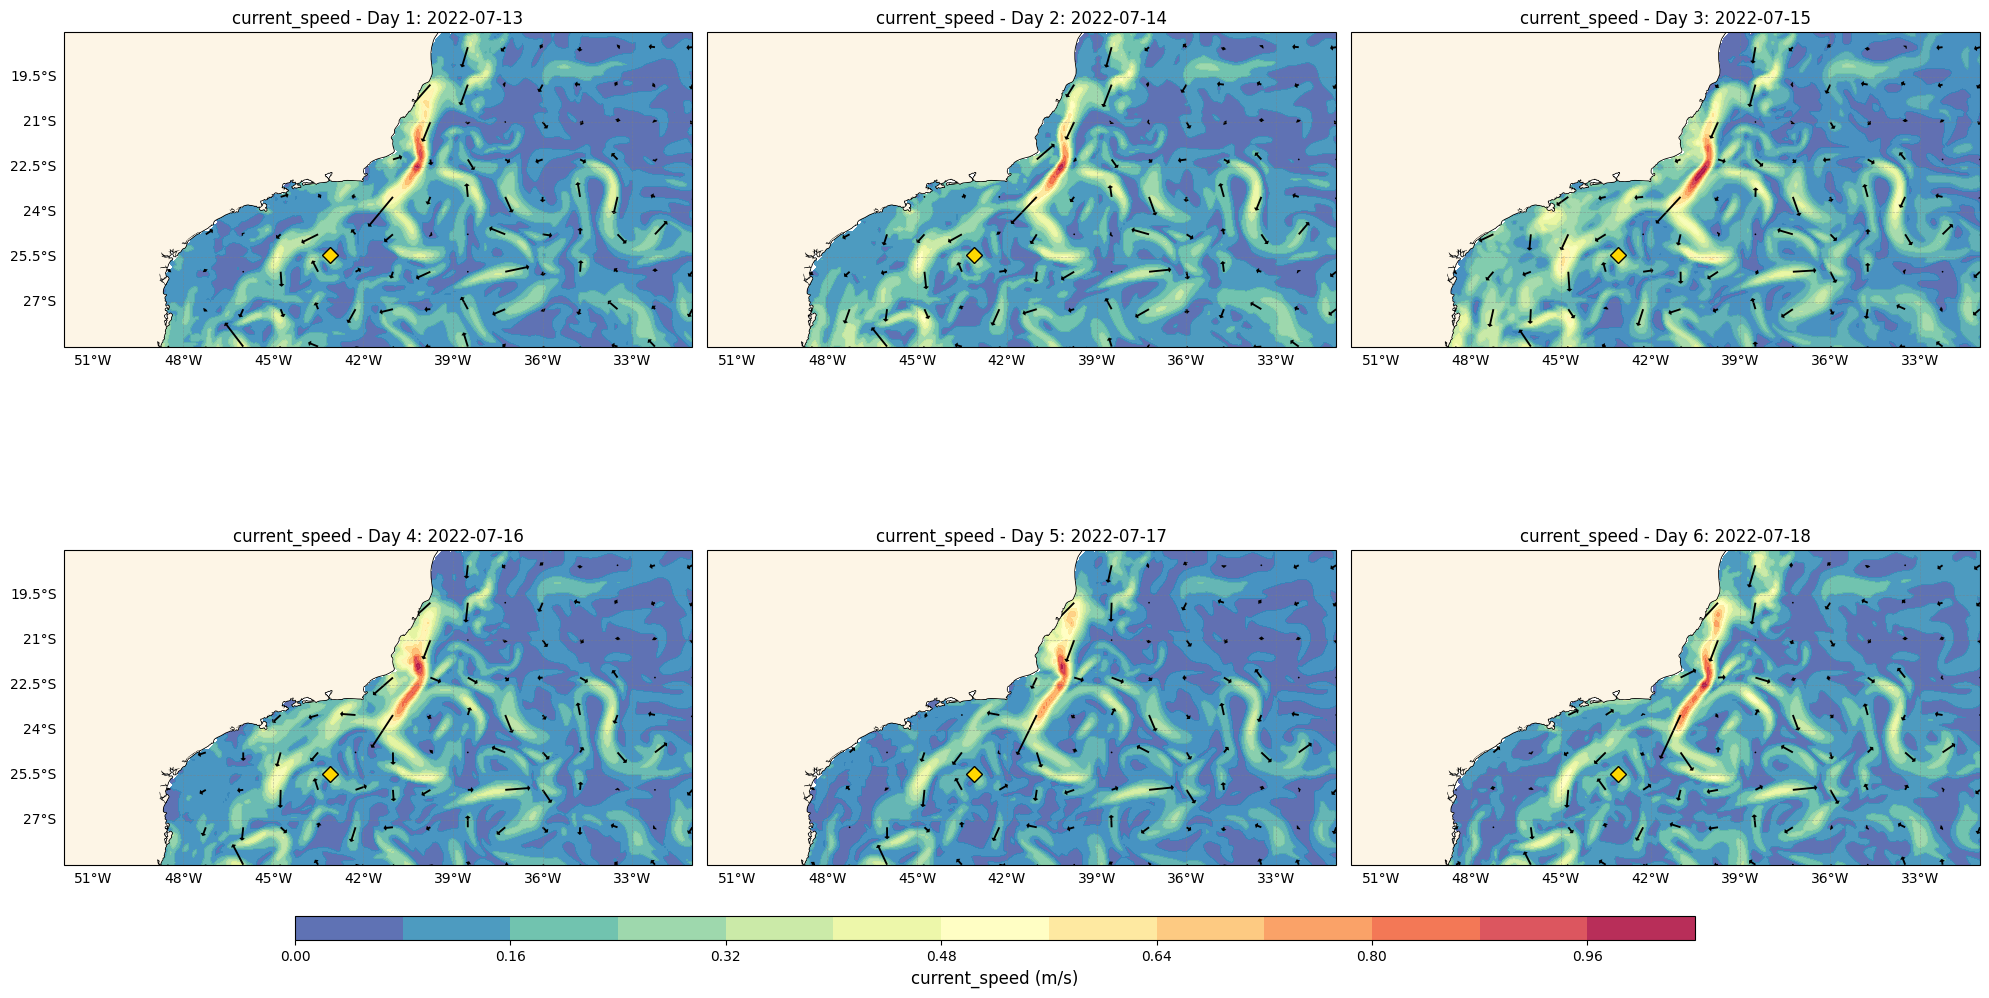

In [548]:
# Create a figure with subplots for each day
fig, axes = plt.subplots(2, 3, figsize=(20, 12), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

# Loop through each day to plot the average current direction
for i, (day_data, day_label) in enumerate(zip(days, day_labels)):
    ax = axes[i]
    
    # Plot the mean current speed as a contour plot
    contour = ax.contourf(
        lon, lat, day_data.mean(dim='valid_time'),
        cmap= 'Spectral_r',
        transform=ccrs.PlateCarree(),
        levels=15,
        alpha=0.9  # Set transparency for better visibility of quiver
    )
    
    # Calculate the mean uo and vo for the day
    uo_mean = uo.sel(valid_time=slice(day_data.valid_time.values[0], day_data.valid_time.values[-1])).mean(dim='valid_time')
    vo_mean = vo.sel(valid_time=slice(day_data.valid_time.values[0], day_data.valid_time.values[-1])).mean(dim='valid_time')
    
    # Add quiver plot for current direction
    ax.quiver(
        lon[::15], lat[::15],  # Downsample for clarity
        uo_mean.values[::15, ::15], vo_mean.values[::15, ::15],
        transform=ccrs.PlateCarree(),
        color='black', scale=10, width=0.003, headlength=1.2, headaxislength=1.6 
    )
    
    # Add coastlines and gridlines
    ax.coastlines()
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False

    try:
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='black')
        ax.add_feature(cfeature.LAND, facecolor='oldlace', zorder=2)
        ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black', zorder=3)

    except ImportError:
        print("Cartopy não está instalado. Por favor, instale-o para adicionar a camada de vetor continental.")
    
    # Remove latitude labels for subplots 1, 2, 4, 5
    if i in [1,2,4,5]:  # Corresponds to subplots 1, 2, 4, 5 (0-indexed)
        gl.left_labels = False

    # Remove labels from subplots 0, 1, 2 (title, x-axis, y-axis labels)
    if i in [0, 1, 2]:
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_title(f'{day_label}', fontsize=10) # Keep only the date
    else:
        ax.set_title(f'{variable_name} - {day_label}', fontsize=12)


    # Mark the two points with colored circles
    ax.plot(
        centroid_point[0], centroid_point[1],
        'D',                    # Circle marker
        color='gold',          # point color  
        markersize=8,
        markeredgecolor='black',
        transform=ccrs.PlateCarree(),
        label='centroide',      #  Define label,
        alpha=1                 # set transparency
    )
    
    # Set title
    ax.set_title(f'{variable_name} - {day_label}', fontsize=12)

# Adjust layout and add a colorbar
plt.tight_layout()
cbar_ax = fig.add_axes([0.15, 0.09, 0.7, 0.02])  # [left, bottom, width, height]
cbar = fig.colorbar(contour, cax=cbar_ax, orientation='horizontal')
cbar.set_label(f'{variable_name} ({unit})', fontsize=12)

#save figure
plt.savefig(f"D:/SARC_LISA_2024/04_dados_finais/figuras_dns_maps/relevant_dates/{relevant_date.date()}_{variable_name}_maps_with_vectors_dns.png", dpi=300)

# Show the plot
plt.show()

## mean sea level pressure

In [549]:
if year <= 2020:
    msl_ds = xr.open_dataset(f"D:/SARC_LISA_2024/01_dados_brutos/dados_de_reanalise/02_parametros_fisicos/ERA5_2016_2023/mean_sea_level_pressure_2016_2024/ERA5_msl_{year}.nc")
elif 2021 <= year <= 2022:
    msl_ds = xr.open_dataset(f"D:/SARC_LISA_2024/01_dados_brutos/dados_de_reanalise/02_parametros_fisicos/ERA5_2016_2023/mean_sea_level_pressure_2016_2024/ERA5_msl_2021_2022.nc")
else:
    msl_ds = xr.open_dataset(f"D:/SARC_LISA_2024/01_dados_brutos/dados_de_reanalise/02_parametros_fisicos/ERA5_2016_2023/mean_sea_level_pressure_2016_2024/ERA5_msl_2023_2024.nc")

In [550]:
msl_ds['msl'] = msl_ds['msl'] / 100  # convert from Pa to hPa
msl_ds = msl_ds.sel(valid_time=slice(start_date, end_date))

In [551]:
dataset = msl_ds # wind_ds # wave_ds # current_ds # msl_ds
variable_name = 'msl'  # 'swh'  # wind_speed  # 'current_speed' # 'e_flux' # 'msl'
variable_label ='Mean Sea Level Pressure (hPa)'  # Significant Wave Height (m)  # Wind Speed (m/s)  # Current Speed (m/s) # 'Wave Energy Flux (kW/m)' # Mean Sea Level Pressure (hPa)
unit = 'hPa'  # 'm'  # 'm/s'  # 'm/s' # 'kW/m' # 'hPa'

In [552]:
lat = dataset.latitude
lon = dataset.longitude

In [553]:
# separe data per day
day_01 = dataset[variable_name].sel(valid_time=slice(start_date, start_date + pd.Timedelta(days=1)))
day_02 = dataset[variable_name].sel(valid_time=slice(start_date + pd.Timedelta(days=1), start_date + pd.Timedelta(days=2)))
day_03 = dataset[variable_name].sel(valid_time=slice(start_date + pd.Timedelta(days=2), start_date + pd.Timedelta(days=3)))
day_04 = dataset[variable_name].sel(valid_time=slice(start_date + pd.Timedelta(days=3), start_date + pd.Timedelta(days=4)))
day_05 = dataset[variable_name].sel(valid_time=slice(start_date + pd.Timedelta(days=4), start_date + pd.Timedelta(days=5)))
day_06 = dataset[variable_name].sel(valid_time=slice(start_date + pd.Timedelta(days=5), start_date + pd.Timedelta(days=6)))


days = [day_01, day_02, day_03, day_04, day_05,day_06]

day_labels = [
    f"Day 1: {start_date.date()}",
    f"Day 2: {(start_date + pd.Timedelta(days=1)).date()}",
    f"Day 3: {(start_date + pd.Timedelta(days=2)).date()}",
    f"Day 4: {(start_date + pd.Timedelta(days=3)).date()}",
    f"Day 5: {(start_date + pd.Timedelta(days=4)).date()}",
    f"Day 6: {(start_date + pd.Timedelta(days=5)).date()}"
]

# find the overall min and max for consistent color scale
all_days_data = [day.mean(dim = 'valid_time') for day in days]
global_min = np.nanmin([np.nanmin(day_data.values) for day_data in all_days_data])
global_max = np.nanmax([np.nanmax(day_data.values) for day_data in all_days_data])


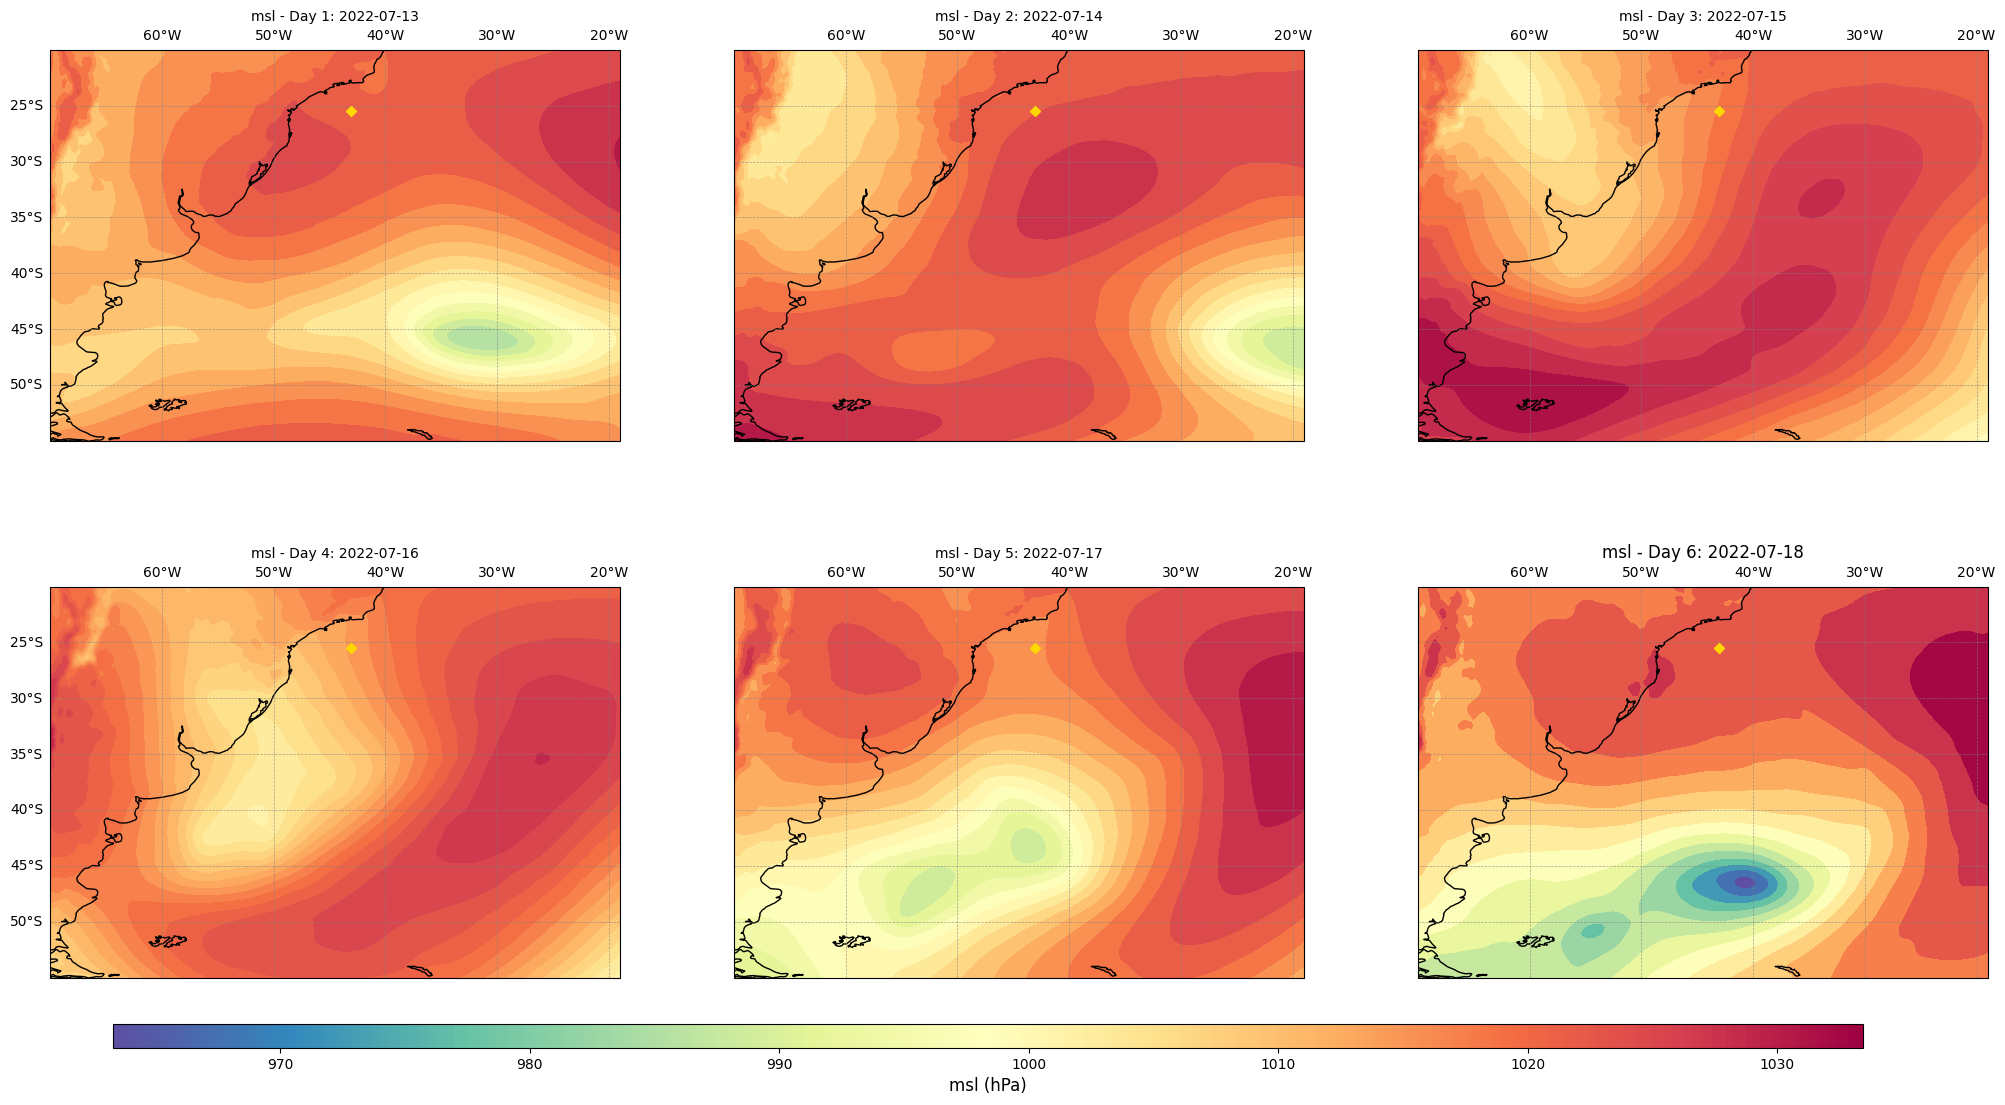

In [554]:

# --- Create figure with consistent color scaling ---
fig = plt.figure(figsize=(25, 12))  # Slightly taller figure to accommodate colorbar
axes = []

# Create a single colorbar for all plots with fixed range
norm = plt.Normalize(vmin=global_min, vmax=global_max)
sm = plt.cm.ScalarMappable(cmap='Spectral_r', norm=norm)
sm.set_array([])  # Empty array, we just need the colormap and normalization

for i in range(len(days)):
    ax = fig.add_subplot(2, 3, i+1, projection=ccrs.PlateCarree())
    axes.append(ax)

for i, (day_data, day_label) in enumerate(zip(days, day_labels)):
    # --- Contour plot with fixed color range ---
    contour = axes[i].contourf(
        lon, lat, day_data.mean(dim='valid_time'), 
        cmap='Spectral_r', 
        transform=ccrs.PlateCarree(),
        norm=norm,  # Use the fixed normalization
        levels=15,
        # alpha = 0.9
    )

    # --- Coastlines and gridlines ---
    axes[i].coastlines()
    gl = axes[i].gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.7, linestyle='--')
    gl.top_labels = True
    gl.left_labels = True
    gl.right_labels = False
    gl.bottom_labels = False
    

    axes[i].plot(
        centroid_point[0], centroid_point[1],
        'D',
        color = 'gold',
        markersize=5,
        transform=ccrs.PlateCarree(),
        label='Centro da área de interesse'  # 'Centro da área de interesse'
    )
    
    # --- Labels and title ---
    axes[i].set_xlabel('Longitude')
    axes[i].set_ylabel('Latitude')
    axes[i].set_title(f'{variable_name} - {day_label}', fontsize=10)

    # Remove latitude labels for subplots 1, 2, 4, 5
    if i in [1,2,4,5]:  # Corresponds to subplots 1, 2, 4, 5 (0-indexed)
        gl.left_labels = False

    # Remove labels from subplots 0, 1, 2 (title, x-axis, y-axis labels)
    if i in [0, 1, 2]:
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_title(f'{day_label}', fontsize=10) # Keep only the date
    else:
        ax.set_title(f'{variable_name} - {day_label}', fontsize=12)


# Adjust layout and add a colorbar
# plt.tight_layout()
cbar_ax = fig.add_axes([0.15, 0.025, 0.7, 0.02])  # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label(f'{variable_name} ({unit})', fontsize=12)

# Adjust layout to make space for the colorbar at the bottom
# plt.tight_layout()
plt.subplots_adjust(bottom=0.06)  # Make extra space at the bottom

plt.savefig(f"D:/SARC_LISA_2024/04_dados_finais/figuras_dns_maps/relevant_dates/{relevant_date.date()}_{variable_name}_maps_dns.png", dpi=300)
# Show the plot
plt.show()